Week 2 Python for Data Analytics

In [27]:
# Week 2 tasks
'''
1. Load a CSV file using Pandas and display basic info.
2. Handle missing values and duplicates using Pandas.
3. Group data by category and find total revenue.
4. Sort data by multiple columns using Python.
5. Create a correlation matrix for numerical columns
'''



'\n1. Load a CSV file using Pandas and display basic info.\n2. Handle missing values and duplicates using Pandas.\n3. Group data by category and find total revenue.\n4. Sort data by multiple columns using Python.\n5. Create a correlation matrix for numerical columns\n'

Task 1
Load a CSV file using Pandas and display basic info

In [28]:
# load + basic info
import pandas as pd
# import numpy as np
df = pd.read_csv('sales_raw.csv')
print(df.head())
print(df.info())
print(df.describe())

   Order_ID        Date     Product     Category  Price Quantity       City
0      1001  2024-01-05      Laptop  Electronics  55000        1      Delhi
1      1002  2024-01-06       Phone  Electronics  30000        2     Mumbai
2      1003  2024-01-07  Headphones  Electronics   2000        3      delhi
3      1004  2024-01-08       Shoes      Fashion   2500        2  Bangalore
4      1005  2024-01-08       Shoes      Fashion   2500        2  Bangalore
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Order_ID  20 non-null     int64
 1   Date      20 non-null     str  
 2   Product   20 non-null     str  
 3   Category  20 non-null     str  
 4   Price     20 non-null     str  
 5   Quantity  19 non-null     str  
 6   City      19 non-null     str  
dtypes: int64(1), str(6)
memory usage: 1.2 KB
None
         Order_ID
count    20.00000
mean   1010.50000
std       5.916

Task 2
Handle missing values and duplicates using Pandas

In [29]:
# missing values + duplicates
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Missing values:
 Order_ID    0
Date        0
Product     0
Category    0
Price       0
Quantity    1
City        1
dtype: int64
Duplicate rows: 0


In [30]:
# handle missing values and duplicates
df = df.drop_duplicates()


In [31]:
# handle city inconsistencies
df['City'] = df['City'].str.strip().str.title()
print(df['City'].unique())
df['City'] = df['City'].replace(pd.NA, 'Unknown')
print(df['City'].unique())

<StringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Chennai', nan, 'Kolkata']
Length: 6, dtype: str
<StringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Unknown', 'Kolkata']
Length: 6, dtype: str


In [32]:
# price to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# price inconsistencies
df.loc[df['Price'] < 0, 'Price'] = pd.NA

In [33]:
# quantity
df['Quantity'] = df['Quantity'].replace({'three': 3})
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [34]:
# fill missing values
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

Saving cleaned data

In [35]:
# save cleaned data to a new CSV file
df.to_csv('cleaned_sales_data.csv', index=False)

Task 3
Group data by category and find total revenue

In [36]:
# find total revenue
df['Revenue'] = df['Price'] * df['Quantity']

# group data by category
category_sales = df.groupby('Category')['Revenue'].sum()
print("Total revenue by category:\n", category_sales)

Total revenue by category:
 Category
Accessories      6000.0
Electronics    394500.0
Fashion         26200.0
Name: Revenue, dtype: float64


Task 4 
Sort data by multiple columns using Python.

In [37]:
# sort data by multiple columns
sorted_df = df.sort_values(
    by=['Category', 'Revenue'], 
    ascending=[True, False]
)
print(sorted_df)

    Order_ID        Date     Product     Category    Price  Quantity  \
8       1009  2024-01-12       Watch  Accessories   1500.0       2.0   
15      1016  2024-01-19       Watch  Accessories   1500.0       2.0   
1       1002  2024-01-06       Phone  Electronics  30000.0       2.0   
7       1008  2024-01-11       Phone  Electronics  30000.0       2.0   
18      1019  2024-01-22       Phone  Electronics  30000.0       2.0   
0       1001  2024-01-05      Laptop  Electronics  55000.0       1.0   
10      1011  2024-01-14      Laptop  Electronics  55000.0       1.0   
17      1018  2024-01-21      Laptop  Electronics  55000.0       1.0   
14      1015  2024-01-18       Phone  Electronics  30000.0       1.0   
2       1003  2024-01-07  Headphones  Electronics   2000.0       3.0   
19      1020  2024-01-23  Headphones  Electronics   2000.0       3.0   
11      1012  2024-01-15  Headphones  Electronics   2500.0       2.0   
6       1007  2024-01-10      Laptop  Electronics   2500.0      

Task 5
Create a correlation matrix for numerical columns

In [38]:
# correlation matrix for numerical columns
numeric = df.select_dtypes(include="number")
print("Correlation matrix:\n", numeric.corr())

Correlation matrix:
           Order_ID     Price  Quantity   Revenue
Order_ID  1.000000 -0.015143 -0.099211 -0.042161
Price    -0.015143  1.000000 -0.454625  0.913246
Quantity -0.099211 -0.454625  1.000000 -0.324888
Revenue  -0.042161  0.913246 -0.324888  1.000000


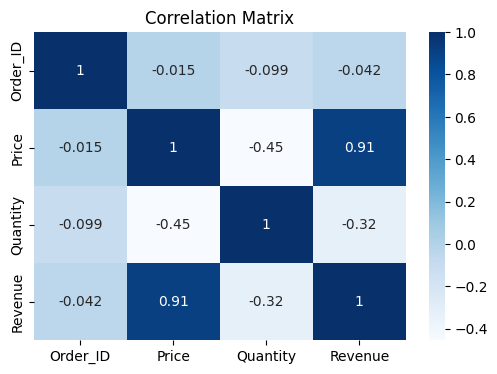

In [39]:
# heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()